# **Проект по компьютерному зрению**

In [18]:
! pip install -r requirements.txt

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# import kagglehub
# 
# # kaggle_api = KGAT_8eb0727ee6d566add6db98054cc75b1f
# kagglehub.login()

In [20]:
# kagglehub.competition_download(
#     "ml-intensive-yandex-academy-spring-2026",
#     output_dir="./data"
# )

'./data'

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import transforms 
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [3]:
def dir_length(
        path: str
) -> int:
    abs_path = os.path.abspath(path)
    return len(os.listdir(abs_path))

In [4]:
class CustomDataset(Dataset):
    def __init__(
            self,
            img_dir: str,
            _train: bool = True,
            csv_path: str = None,
            _transform: transforms.Compose = None
    ):
        self.img_dir = img_dir
        self.train = _train
        self.data = pd.read_csv(
            csv_path, names=["id", "label"]
        ) if _train else None
        self._transform = _transform
    
    def __len__(self):
        return dir_length(self.img_dir)
    
    def __getitem__(
            self,
            idx: int
    ):
        if self.train:
            label = torch.tensor(
                self.data.iloc[idx]["label"],
                dtype=torch.float32
            )  
        else:
            label = idx
            
        path = os.path.join(self.img_dir, f"{idx}.jpg")
        img = Image.open(path).convert("RGB")
        if self._transform:
            img = self._transform(img)
            
        return img, label

In [5]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

dataset = CustomDataset(
    img_dir="./data/dataset/train_images",
    csv_path="./data/dataset/train_solution.csv",
    _train=True,
    _transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

BATCH_SIZE = 128

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

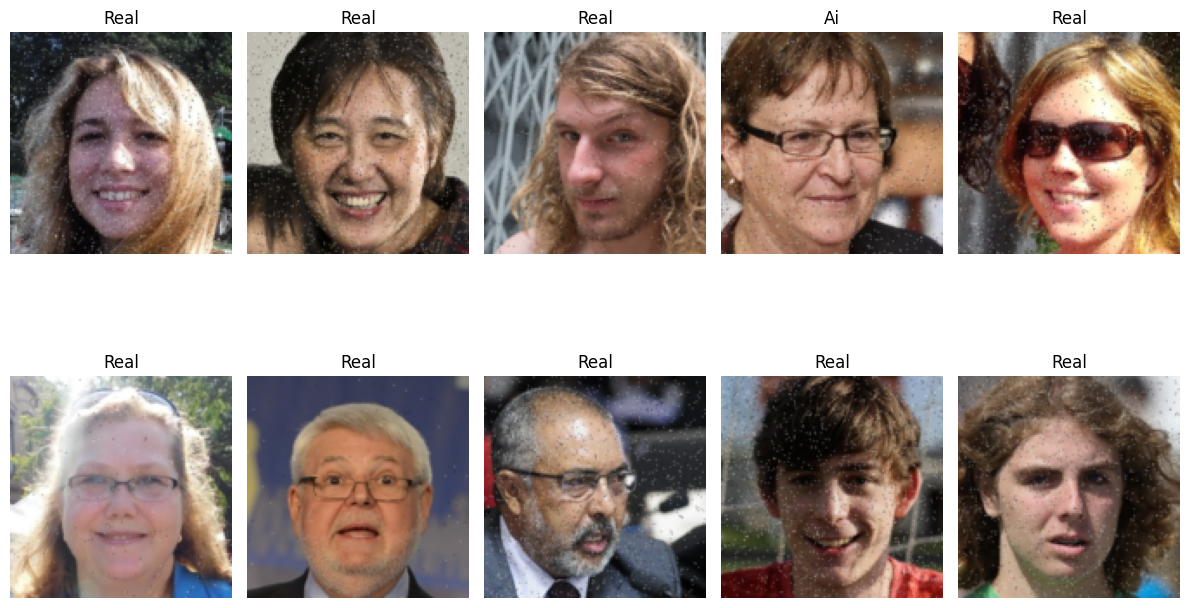

In [6]:
to_pil = transforms.ToPILImage()


def imshow(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")

dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    imshow(images[i])
    plt.title("Real" if labels[i].item() == 0 else "Ai")
plt.tight_layout()
plt.show()

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = CNN().to(device)
model

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [8]:
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             448
              ReLU-2         [-1, 16, 128, 128]               0
         MaxPool2d-3           [-1, 16, 64, 64]               0
            Conv2d-4           [-1, 32, 64, 64]           4,640
              ReLU-5           [-1, 32, 64, 64]               0
         MaxPool2d-6           [-1, 32, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          18,496
              ReLU-8           [-1, 64, 32, 32]               0
         MaxPool2d-9           [-1, 64, 16, 16]               0
          Flatten-10                [-1, 16384]               0
           Linear-11                  [-1, 128]       2,097,280
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 1]             129
          Sigmoid-14                   

In [9]:
LEARNING_RATE = 0.01

criterion = nn.BCELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [10]:
def show_losses(
        train_loss_hist,
        train_accs_hist,
        val_loss_hist,
        val_accs_hist
):
    clear_output()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_hist, label="Train loss")
    plt.plot(val_loss_hist, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss curves")

    plt.subplot(1, 2, 2)
    plt.plot(train_accs_hist, label="Train acc")
    plt.plot(val_accs_hist, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy curves")

    plt.tight_layout()
    plt.show()

In [11]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    for img, labels in loader:
        img, labels = img.to(device), labels.to(device).unsqueeze(1)
        outputs = model(img)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


@torch.inference_mode()  # no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    
    for img, labels in loader:
        img, labels = img.to(device), labels.to(device).unsqueeze(1)
        outputs = model(img)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    
    return avg_loss, accuracy

In [12]:
def train(
        model,
        _train_loader,
        _val_loader,
        epochs=10
):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, _train_loader)
        val_loss, val_acc = evaluate(model, _val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        show_losses(
            train_loss_hist=train_losses,
            train_accs_hist=train_accs,
            val_loss_hist=val_losses,
            val_accs_hist=val_accs
        )
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

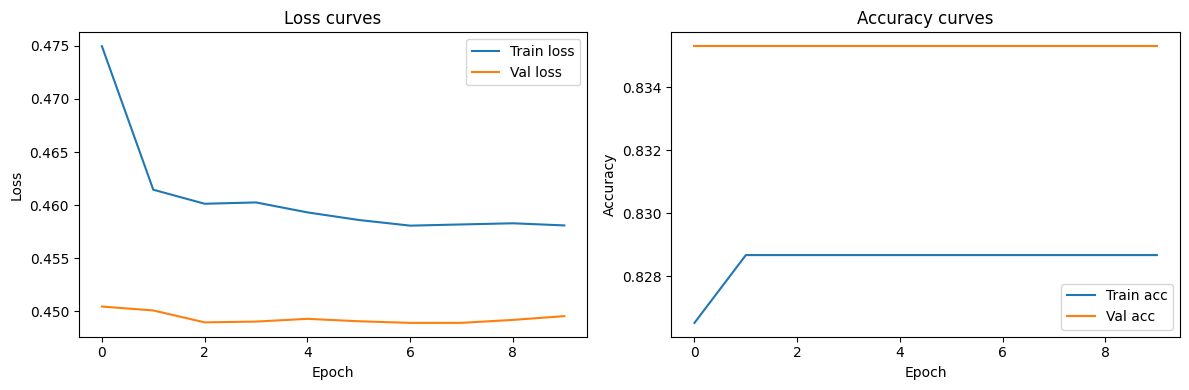

Epoch 10/10 | Train Loss: 0.4581 | Train Acc: 0.8287 | Val Loss: 0.4495 | Val Acc: 0.8353


In [31]:
train(
    model=model,
    _train_loader=train_loader,
    _val_loader=val_loader,
    epochs=10
)

In [32]:
test_dataset = CustomDataset(
    img_dir="./data/dataset/test_images",
    _train=False,
    _transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [33]:
def predict(model, test_loader):
    model.eval()

    predictions = []

    with torch.no_grad():
        for imges, img_ids in test_loader:
            imges = imges.to(device)

            outputs = model(imges)
            probs = outputs.squeeze()

            preds = (probs > 0.5).int().cpu().numpy()        
            for img_id, pred in zip(img_ids, preds):
                predictions.append((img_id.item(), pred))

    return predictions

In [34]:
preds = predict(model, test_loader)
df = pd.DataFrame(preds, columns=["id", "label"])
df = df.sort_values("id")
df

,id,label
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


In [38]:
a = df.filter
a

,id,label
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
9995,NaN,NaN
9996,NaN,NaN
9997,NaN,NaN
9998,NaN,NaN
